In [67]:
import pandas as pd
import os
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

In [68]:
df_ground_truth = pd.read_pickle('../Ground truth/outputs/ground_truth_processed.pkl')

In [13]:
df_course_level = pd.read_pickle('../data/selected_universities_course_level_embeddings.pkl')
# df_course_level.info()
# reduced 4618936 to 896770 using embeddings - a diff of 3722166


In [14]:
# merge_cols = ['cat_type', 'start_yr', 'end_yr', 'Department', 'Number', 'Title']
merge_cols = ['id_department_course', 'id_catalog']

# Merge the dataframes
eval_df = df_ground_truth.merge(
    df_course_level[merge_cols + ['max_cos_similarity', 'best_matching_keyword']],
    on=merge_cols,
    # suffixes = ('groundtruth','courselevel'),
    how='left'  # or 'left' to keep all ground truth entries
)

### AI vs Non-AI for different thresholds 

In [16]:
# Filter to courses only
courses_df = eval_df[eval_df['is_not_course'] == 0].copy()
courses_df['max_cos_similarity'] = courses_df['max_cos_similarity'].fillna(0)


total_ai = courses_df['has_ai'].sum()
total_non_ai = (courses_df['has_ai'] == 0).sum()

print(f"Ground Truth: {total_ai} AI courses, {total_non_ai} non-AI courses")
print("\n" + "="*70)
print(f"{'Threshold':<12} {'Total':<10} {'AI':<10} {'Non-AI':<10}")
print("="*70)

for threshold in [0.1 * i for i in range(11)]:
    matched = courses_df[courses_df['max_cos_similarity'] >= threshold]
    
    ai_count = matched['has_ai'].sum()
    non_ai_count = (matched['has_ai'] == 0).sum()
    total = len(matched)
    
    print(f"{threshold:<12.1f} {total:<10d} {ai_count:<10d} {non_ai_count:<10d}")

Ground Truth: 7 AI courses, 2952 non-AI courses

Threshold    Total      AI         Non-AI    
0.0          2959       7          2952      
0.1          2843       7          2836      
0.2          1633       7          1626      
0.3          430        7          423       
0.4          102        7          95        
0.5          32         4          28        
0.6          7          1          6         
0.7          1          0          1         
0.8          0          0          0         
0.9          0          0          0         
1.0          0          0          0         


In [52]:
ai_courses = courses_df[courses_df['has_ai'] == 1].copy()

print("AI Courses by Similarity Score:")
print(ai_courses[['Department', 'Number', 'Title', 'max_cos_similarity', 'best_matching_keyword']].sort_values('max_cos_similarity', ascending=False))

AI Courses by Similarity Score:
                             Department Number  \
1939                   computer science    384   
172                             english   223E   
330   hiatry and biobehavioral sciences   M209   
987                          statistics    180   
122                                 cse   262Z   
1486                   computer science    351   
176                quantitative methods   214B   

                                                  Title  max_cos_similarity  \
1939                            Artificial Intelligence            0.631646   
172   Heuristic Programming And Artificial Intelligence            0.594652   
330   M209. Introduction To Neural Networks: Modelin...            0.580759   
987                 Introduction To Bayesian Statistics            0.555500   
122                 Current Topics In Cognitive Systems            0.472733   
1486  Advanced Topics In Pattern Analysis And Artifi...            0.462878   
176           

### Classification prediction task: ROC Curve, precision, recall, accuracy and f1-score

AUC: 0.9914208598419124


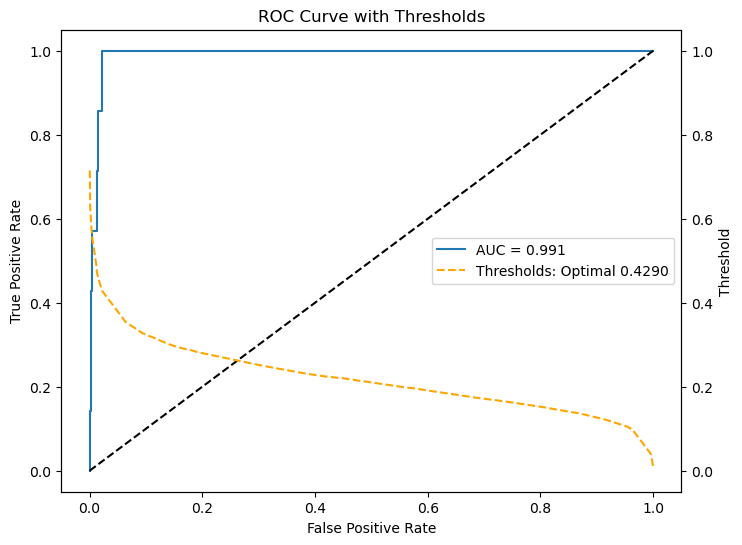

In [54]:
# Ground truth labels and prediction scores
y_true = eval_df['has_ai']
y_scores = eval_df['max_cos_similarity']

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Compute AUC
auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

fig, ax1 = plt.subplots(figsize=(8, 6))

# --- Primary axis: ROC curve ---
ax1.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
ax1.plot([0, 1], [0, 1], linestyle="--", color="black")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve with Thresholds")
ax1.set_ylim([-0.05,1.05])
# ax1.legend(loc="lower right")

# --- Secondary axis: thresholds aligned to TPR ---
ax2 = ax1.twinx()
optimal_threshold = thresholds[np.argmax(tpr-fpr)]
ax2.plot(fpr, thresholds, linestyle="--", color="orange", label="Thresholds: Optimal {:.4f}".format(optimal_threshold))
ax2.set_ylim([-0.05,1.05])
ax2.set_ylabel("Threshold")

# Optional: show threshold legend
# ax2.legend(loc="upper right")
# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")


plt.show()


In [51]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score

# Input threshold
threshold = optimal_threshold   # <--- change as needed

# Convert scores to binary predictions
y_pred = (y_scores >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nMetrics:")
print("Precision:", precision)
print("Recall:", recall)
print("Accuracy:", accuracy)
print("F1 Score:", f1)


Confusion Matrix:
[[2900   64]
 [   0    7]]
TN=2900, FP=64, FN=0, TP=7

Metrics:
Precision: 0.09859154929577464
Recall: 1.0
Accuracy: 0.9784584315045439
F1 Score: 0.1794871794871795


In [53]:
optimal_threshold

np.float32(0.42900878)